In [1]:
# Imports
import numpy as np
import pandas as pd
from scipy.stats import linregress
from tqdm import tqdm
import matplotlib.pyplot as plt

# Summary

This notebook contains functions for computing Elo ratings during regular seasons and tournaments, summarizing team performance in both men's and women's events. It produces two ready to use CSV files containing the following key team information:

- **Rating_Mean:** The average team rating in a regular season.
- **Rating_Median:** The median team rating in a regular season.
- **Rating_Last:** The last rating in a regular season/ the final rating before the tournament.
- **Rating_Std:** Standard Deviation of team ratings.
- **Rating_Max:** The maximum team rating in a season.
- **Rating_Min:** The minimum team rating in a season.
- **Rating_Trend:** The slope of the team's rating over the season.

# Functions

In [2]:
def calculate_elo(
    teams, data, initial_rating=2000, k=140, alpha=None, weights=False, nan_score=1
):
    """
    Calculate Elo ratings for each team based on match data.

    Parameters:
    - teams (array-like): Containing Team-IDs.
    - data (pd.DataFrame): DataFrame with all matches in chronological order.
    - initial_rating (float): Initial rating of an unranked team (default: 2000).
    - k (float): K-factor, determining the impact of each match on team ratings (default: 140).
    - alpha (float or None): Tuning parameter for the multiplier for the margin of victory. No multiplier if None.

    Returns:
    - list: Historical ratings of the winning team (WTeam).
    - list: Historical ratings of the losing team (LTeam).
    """

    # Dictionary to keep track of current ratings for each team
    team_dict = {}
    for team in teams:
        team_dict[team] = initial_rating

    # Lists to store ratings for each team in each game
    r1, r2 = [], []
    loss = []
    margin_of_victory = 1
    weight = 1

    # Iterate through the game data
    for wteam, lteam, ws, ls, w in tqdm(
        zip(data.WTeamID, data.LTeamID, data.WScore, data.LScore, data.weight),
        total=len(data),
    ):
        # Calculate expected outcomes based on Elo ratings
        rateW = 1 / (1 + 10 ** ((team_dict[lteam] - team_dict[wteam]) / initial_rating))
        rateL = 1 / (1 + 10 ** ((team_dict[wteam] - team_dict[lteam]) / initial_rating))

        if alpha:
            margin_of_victory = (ws - ls) / alpha
        if isinstance(weights, (list, np.ndarray, pd.Series)):
            weight = w

        # Update ratings for winning and losing teams
        team_dict[wteam] += w * k * margin_of_victory * (1 - rateW)
        team_dict[lteam] += w * k * margin_of_victory * (0 - rateL)

        # Ensure that ratings do not go below 1
        if team_dict[lteam] < 1:
            team_dict[lteam] = 1

        # Append current ratings for teams to lists
        r1.append(team_dict[wteam])
        r2.append(team_dict[lteam])
        loss.append((1 - rateW) ** 2)

    return r1, r2, loss


def create_elo_data(
    teams, data, initial_rating=2000, k=140, alpha=None, weights=None, nan_score=1
):
    """
    Create a DataFrame with summary statistics of Elo ratings for teams based on historical match data.

    Parameters:
    - teams (array-like): Containing Team-IDs.
    - data (pd.DataFrame): DataFrame with all matches in chronological order.
    - initial_rating (float): Initial rating of an unranked team (default: 2000).
    - k (float): K-factor, determining the impact of each match on team ratings (default: 140).
    - weights (array-like): Containing weights for each match.

    Returns:
    - DataFrame: Summary statistics of Elo ratings for teams throughout a season.
    """

    if isinstance(weights, (list, np.ndarray, pd.Series)):
        data["weight"] = weights
    else:
        data["weight"] = 1

    r1, r2, loss = calculate_elo(
        teams, data, initial_rating, k, alpha, weights, nan_score
    )
    # Calculate loss only on tourney results
    loss = np.mean(np.array(loss)[data.tourney == 1])
    print(f"Loss: {loss}")

    # Concatenate arrays vertically
    seasons = np.concatenate([data.Season, data.Season])
    days = np.concatenate([data.DayNum, data.DayNum])
    teams = np.concatenate([data.WTeamID, data.LTeamID])
    tourney = np.concatenate([data.tourney, data.tourney])
    ratings = np.concatenate([r1, r2])
    # Create a DataFrame
    rating_df = pd.DataFrame(
        {
            "Season": seasons,
            "DayNum": days,
            "TeamID": teams,
            "Rating": ratings,
            "Tourney": tourney,
        }
    )

    # Sort DataFrame and remove tournament data
    rating_df.sort_values(["TeamID", "Season", "DayNum"], inplace=True)
    rating_df = rating_df[rating_df["Tourney"] == 0]
    grouped = rating_df.groupby(["TeamID", "Season"])
    results = grouped["Rating"].agg(["mean", "median", "std", "min", "max", "last"])
    results.columns = [
        "Rating_Mean",
        "Rating_Median",
        "Rating_Std",
        "Rating_Min",
        "Rating_Max",
        "Rating_Last",
    ]
    results["Rating_Trend"] = grouped.apply(
        lambda x: linregress(range(len(x)), x["Rating"]).slope, include_groups=False
    )
    results.reset_index(inplace=True)

    return results

# Apply Functions and Save Results to CSV

In [3]:
# Load and Process Data Men's Tourney
regular_m = pd.read_csv(
    "/kaggle/input/march-machine-learning-mania-2025/MRegularSeasonCompactResults.csv"
)
tourney_m = pd.read_csv(
    "/kaggle/input/march-machine-learning-mania-2025/MNCAATourneyCompactResults.csv"
)
teams_m = pd.read_csv("/kaggle/input/march-machine-learning-mania-2025/MTeams.csv")

regular_m["tourney"] = 0
tourney_m["tourney"] = 1
regular_m["weight"] = 1
tourney_m["weight"] = 0.7

data_m = pd.concat([regular_m, tourney_m])
data_m.sort_values(["Season", "DayNum"], inplace=True)
data_m.reset_index(inplace=True, drop=True)

elo_df_men = create_elo_data(
    teams_m.TeamID,
    data_m,
    initial_rating=1200,
    k=125,
    alpha=None,
    weights=data_m["weight"],
)
elo_df_men.tail(10)

100%|██████████| 195015/195015 [00:00<00:00, 350350.54it/s]


Loss: 0.1881333201818146


,TeamID,Season,Rating_Mean,Rating_Median,Rating_Std,Rating_Min,Rating_Max,Rating_Last,Rating_Trend
13378,1476,2023,931.719917,895.701809,136.140818,738.312853,1194.639608,738.312853,-13.415252
13379,1476,2024,375.030934,354.742230,261.932970,45.364699,783.904415,69.180722,-28.922216
13380,1476,2025,349.527063,410.148227,159.294266,30.663400,550.679074,460.605361,15.817448
13381,1477,2023,903.287972,877.330304,183.711694,552.118002,1207.753474,552.118002,-18.574070
13382,1477,2024,500.435154,480.375796,107.970960,357.339166,697.426537,455.729827,-8.976228
13383,1477,2025,237.919561,205.835790,138.841360,64.750953,478.517464,167.597536,-13.737078
13384,1478,2024,879.306603,857.121073,126.023701,675.262993,1153.694341,786.575661,-12.825440
13385,1478,2025,533.333317,523.275204,171.874812,235.861304,796.885877,235.861304,-19.408222
13386,1479,2025,900.485999,870.186116,155.521011,681.700618,1216.762951,803.343585,-16.012280
13387,1480,2025,763.076712,752.097531,201.509257,447.030751,1190.078762,538.771753,-22.170291


In [4]:
# Load and Process Data Women's Tourney
regular_w = pd.read_csv(
    "/kaggle/input/march-machine-learning-mania-2025/WRegularSeasonCompactResults.csv"
)
tourney_w = pd.read_csv(
    "/kaggle/input/march-machine-learning-mania-2025/WNCAATourneyCompactResults.csv"
)
teams_w = pd.read_csv("/kaggle/input/march-machine-learning-mania-2025/WTeams.csv")

regular_w["tourney"] = 0
tourney_w["tourney"] = 1
regular_w["weight"] = 0.95
tourney_w["weight"] = 1

data_w = pd.concat([regular_w, tourney_w])
data_w.sort_values(["Season", "DayNum"], inplace=True)
data_w.reset_index(inplace=True, drop=True)

elo_df_women = create_elo_data(
    teams_w.TeamID,
    data_w,
    initial_rating=1250,
    k=190,
    alpha=None,
    weights=data_w["weight"],
)
elo_df_women.tail(10)

100%|██████████| 138278/138278 [00:00<00:00, 361435.93it/s]


Loss: 0.14833960933719387


,TeamID,Season,Rating_Mean,Rating_Median,Rating_Std,Rating_Min,Rating_Max,Rating_Last,Rating_Trend
9478,3476,2023,701.603386,720.890556,339.329273,185.601150,1183.285994,392.358568,-39.189371
9479,3476,2024,143.129069,117.099414,113.164827,1.000000,379.754363,1.000000,-9.653519
9480,3476,2025,351.168054,377.287277,194.724951,1.000000,685.416359,635.335091,23.025648
9481,3477,2023,988.266000,1009.666062,158.067534,660.392613,1244.576874,778.098922,-12.410521
9482,3477,2024,924.704477,940.653005,135.760663,669.626804,1157.730424,946.937686,-5.602027
9483,3477,2025,541.127315,474.331584,225.543997,239.051061,937.533050,359.330777,-25.516842
9484,3478,2024,1185.515596,1175.425443,84.995362,996.141290,1382.897330,1302.645448,5.665488
9485,3478,2025,736.297496,636.815206,344.584326,259.498930,1301.310936,359.626439,-40.311734
9486,3479,2025,656.329002,560.588642,274.797481,259.071275,1249.092192,259.071275,-34.256223
9487,3480,2025,980.182596,1007.630442,99.052244,752.316942,1150.055205,1081.722922,-6.189917


In [5]:
# Save to csv
elo_df_men.to_csv("mens_elo_rating.csv")
elo_df_women.to_csv("womens_elo_rating.csv")

# Top 20 Teams Based on Latest Data-Update (07.03.2025)

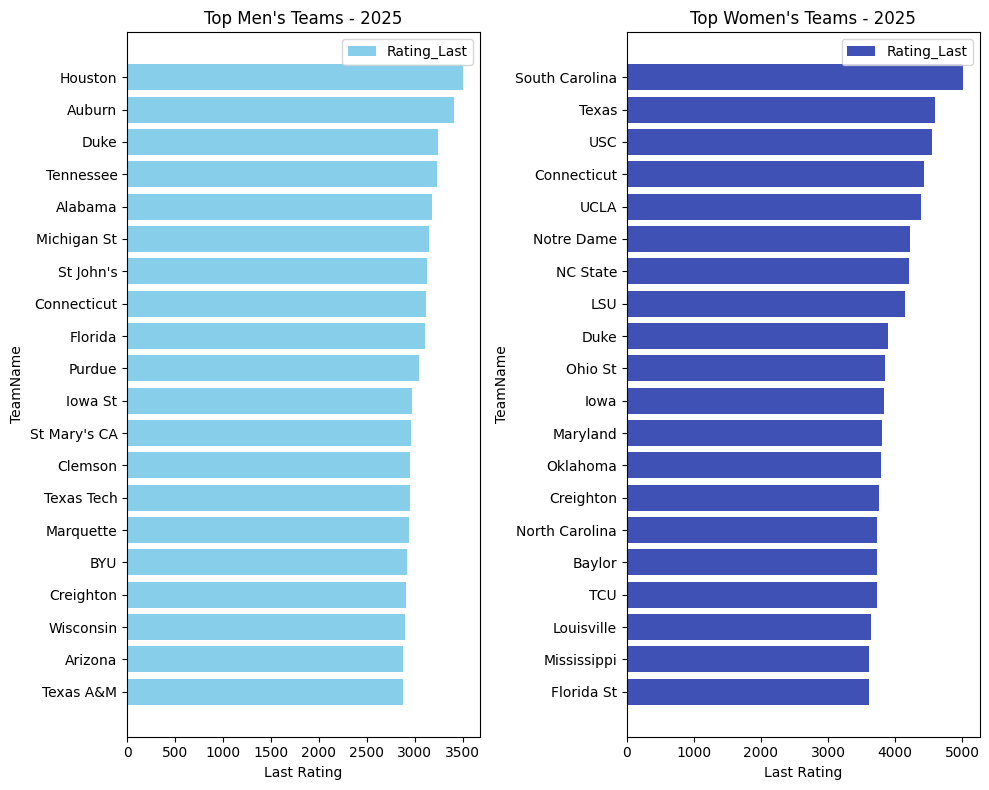

In [6]:
# Men's Teams
tmp_df_men = pd.merge(elo_df_men, teams_m, on="TeamID", how="left")
tmp_df_men = tmp_df_men[tmp_df_men["Season"] == 2025]
top_men_teams = tmp_df_men.sort_values("Rating_Last", ascending=False)[:20][
    ["TeamName", "Rating_Last", "Rating_Trend"]
]
top_men_teams = top_men_teams.reindex(index=top_men_teams.index[::-1])

# Women's Teams
tmp_df_women = pd.merge(elo_df_women, teams_w, on="TeamID", how="left")
tmp_df_women = tmp_df_women[tmp_df_women["Season"] == 2025]
top_women_teams = tmp_df_women.sort_values("Rating_Last", ascending=False)[:20][
    ["TeamName", "Rating_Last", "Rating_Trend"]
]
top_women_teams = top_women_teams.reindex(index=top_women_teams.index[::-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

# Men's Teams
ax1.barh(
    top_men_teams["TeamName"],
    top_men_teams["Rating_Last"],
    color="skyblue",
    label="Rating_Last",
)
ax1.set_title("Top Men's Teams - 2025")
ax1.set_xlabel("Last Rating")
ax1.set_ylabel("TeamName")
ax1.legend()

# Women's Teams
ax2.barh(
    top_women_teams["TeamName"],
    top_women_teams["Rating_Last"],
    color="#3F51B5",
    label="Rating_Last",
)
ax2.set_title("Top Women's Teams - 2025")
ax2.set_xlabel("Last Rating")
ax2.set_ylabel("TeamName")
ax2.legend()

plt.tight_layout()
plt.show()